iter 366: stagnated → injected noise, loss=0.000435
iter 466: stagnated → injected noise, loss=0.000435
iter 566: stagnated → injected noise, loss=0.000435
iter 666: stagnated → injected noise, loss=0.000435
iter 766: stagnated → injected noise, loss=0.000435
iter 866: stagnated → injected noise, loss=0.000435
iter 966: stagnated → injected noise, loss=0.000435
Initial L2 discrepancy: 0.043237260509622316
Best L2 discrepancy value: 0.020865119416323467


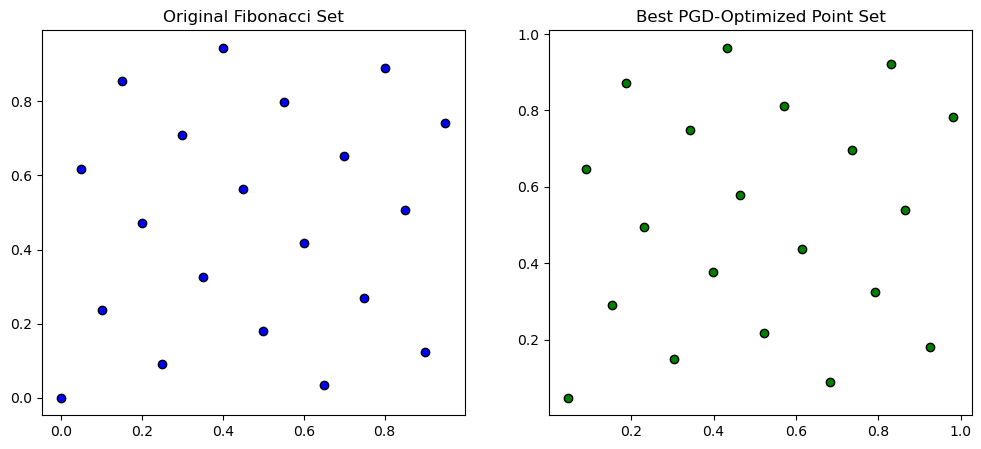

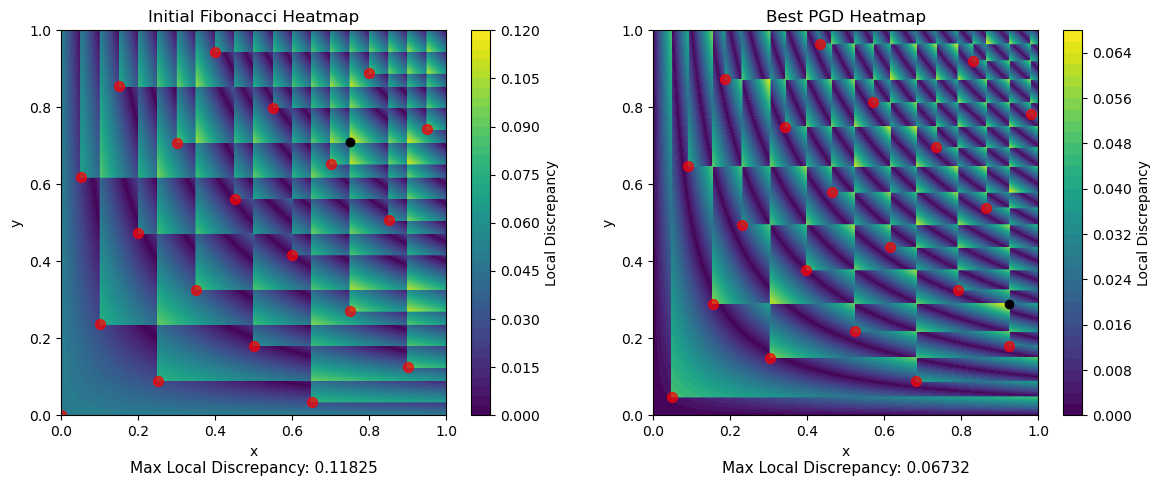

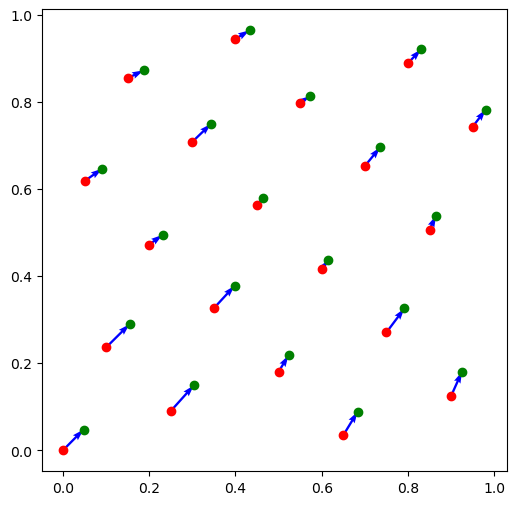

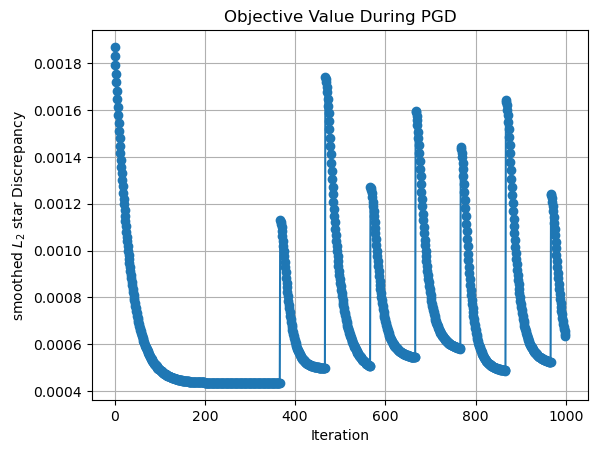

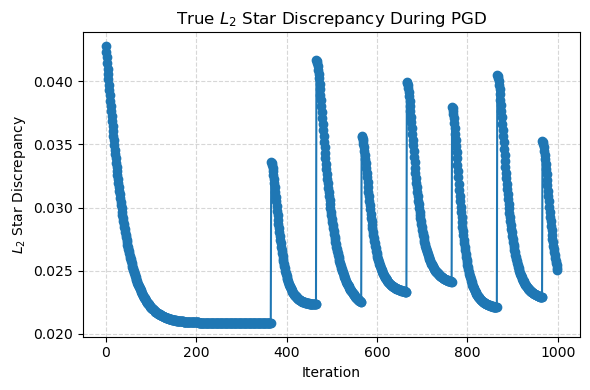

Optimal L2‐star discrepancy achieved: 0.020862


In [33]:
import jax
import jax.numpy as jnp
import optax
import numpy as np

# … your helper-functions here …

# how many points in your set?
n = 20

# build the INITIAL fibonacci set of size n
P_init     = fibonacci_lattice(n)
init_points = np.asarray(P_init).astype(np.float64)

# now P and best_P both start from the same n-point set
P      = P_init
best_P = P_init
# ADAM optimizer setup
learning_rate = 5e-4
optimizer     = optax.adam(learning_rate)

# noise-injection hyper-parameters
n_iters    = 1000
patience   = 100
flat_eps   = 1e-7
noise_scale= 0.05

# … all your existing setup …
opt_state     = optimizer.init(P)

# track true L2‐star discrepancy over time
l2_history = []


# PRNG
key = jax.random.PRNGKey(42)

loss_fn       = lambda P: L2_smoothed(P)
loss_and_grad = jax.value_and_grad(loss_fn)
opt_state     = optimizer.init(P)


best_loss, _ = loss_and_grad(P)
stagnation = 0
objective_history = []

for i in range(n_iters):
    loss_val, grads = loss_and_grad(P)
    objective_history.append(loss_val)

    # 1) Update “best so far”
    if loss_val + flat_eps < best_loss:
        best_loss = loss_val
        best_P = P
        stagnation = 0
    else:
        stagnation += 1

    # 2) If stagnated for too long, perturb the best iterate
    if stagnation >= patience:
        key, subkey = jax.random.split(key)
        noise = noise_scale * jax.random.normal(subkey, best_P.shape)
        P = jnp.clip(best_P + noise, 0.0, 1.0)
        # reset optimizer state if you like, or continue with same opt_state
        # opt_state = optimizer.init(P)
        stagnation = 0
        # optionally log
        print(f"iter {i}: stagnated → injected noise, loss={best_loss:.6f}")

    # 3) Regular gradient-step from wherever P is now
    updates, opt_state = optimizer.update(grads, opt_state)
    P = optax.apply_updates(P, updates)
    P = jnp.clip(P, 0.0, 1.0)

    l2_history.append(
        L2_discrepancy( np.asarray(P) )
        )

# After the loop, you can choose best_P (with best_loss) or final P


init_points = np.asarray(P_init).astype(np.float64)
best_points = np.asarray(best_P).astype(np.float64)
initial_discrepancy_value = L2_discrepancy(init_points)

# === Side-by-side: point sets ===
# === Side-by-side: point sets ===
fig, axs = plt.subplots(1, 2, figsize=(12, 5))

axs[0].scatter(init_points[:, 0], init_points[:, 1], c='blue', edgecolor='black')
axs[0].set_title("Original Fibonacci Set")
# …

axs[1].scatter(best_points[:, 0], best_points[:, 1], c='green', edgecolor='black')
axs[1].set_title("Best PGD-Optimized Point Set")
# …

# === Side-by-side: heatmaps ===
fig, axs = plt.subplots(1, 2, figsize=(14, 5))

_, max_init = heatmap_from_array(init_points, ax=axs[0])
axs[0].set_title("Initial Fibonacci Heatmap")
axs[0].text(0.5, -0.15, f"Max Local Discrepancy: {max_init:.5f}",
            transform=axs[0].transAxes, ha='center', fontsize=11)

_, max_best = heatmap_from_array(best_points, ax=axs[1])
axs[1].set_title("Best PGD Heatmap")
axs[1].text(0.5, -0.15, f"Max Local Discrepancy: {max_best:.5f}",
            transform=axs[1].transAxes, ha='center', fontsize=11)

# === Output ===
print("Initial L2 discrepancy:", initial_discrepancy_value)
print("Best L2 discrepancy value:", L2_discrepancy(best_points))

dx = best_points[:, 0] - init_points[:, 0]
dy = best_points[:, 1] - init_points[:, 1]

plt.figure(figsize=(6, 6))
plt.quiver(
    init_points[:, 0], init_points[:, 1],
    dx, dy, angles='xy', scale_units='xy', scale=1,
    color='blue', width=0.005
)
plt.scatter(init_points[:, 0], init_points[:, 1], c='red', label='Initial')
plt.scatter(best_points[:, 0], best_points[:, 1], c='green', label='Best')

plt.figure()
plt.plot(objective_history, marker='o')
plt.title("Objective Value During PGD")
plt.xlabel("Iteration")
plt.ylabel("smoothed $L_2$ star Discrepancy")
plt.grid(True)
plt.show()
# …

# === True L2‐star Discrepancy over Iterations ===
plt.figure(figsize=(6,4))
plt.plot(l2_history, marker='o')
plt.title("True $L_2$ Star Discrepancy During PGD")
plt.xlabel("Iteration")
plt.ylabel("$L_2$ Star Discrepancy")
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

best_l2 = min(l2_history)
print(f"Optimal L2‐star discrepancy achieved: {best_l2:.6f}")

iter 55: stagnated → injected noise, loss=0.000004
iter 105: stagnated → injected noise, loss=0.000004
iter 155: stagnated → injected noise, loss=0.000004
iter 205: stagnated → injected noise, loss=0.000004
iter 255: stagnated → injected noise, loss=0.000004
iter 305: stagnated → injected noise, loss=0.000004
iter 355: stagnated → injected noise, loss=0.000004
iter 405: stagnated → injected noise, loss=0.000004
iter 455: stagnated → injected noise, loss=0.000004
iter 505: stagnated → injected noise, loss=0.000004
iter 555: stagnated → injected noise, loss=0.000004
iter 605: stagnated → injected noise, loss=0.000004
iter 655: stagnated → injected noise, loss=0.000004
iter 705: stagnated → injected noise, loss=0.000004
iter 755: stagnated → injected noise, loss=0.000004
iter 805: stagnated → injected noise, loss=0.000004
iter 855: stagnated → injected noise, loss=0.000004
iter 905: stagnated → injected noise, loss=0.000004
iter 955: stagnated → injected noise, loss=0.000004
Initial L2 di

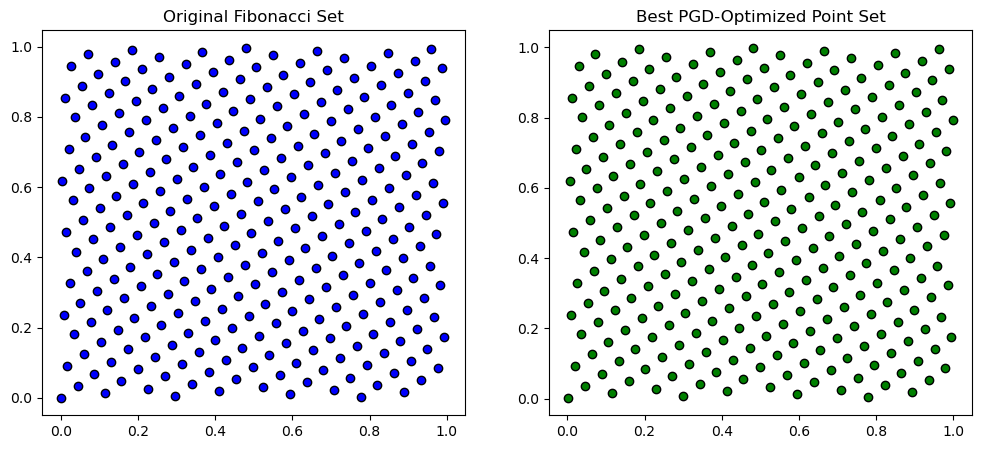

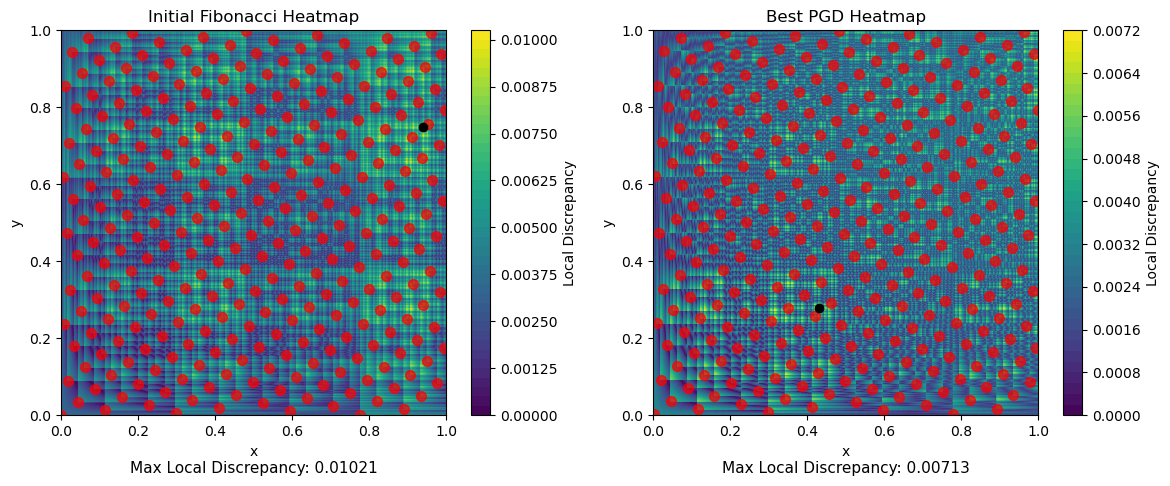

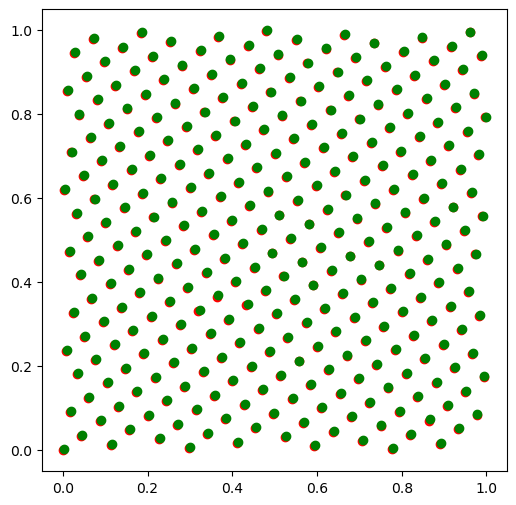

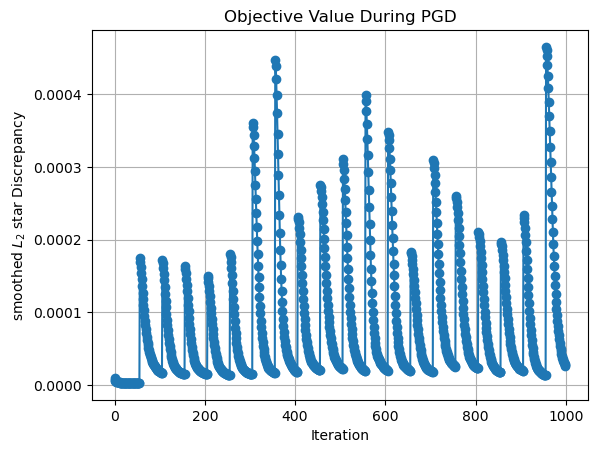

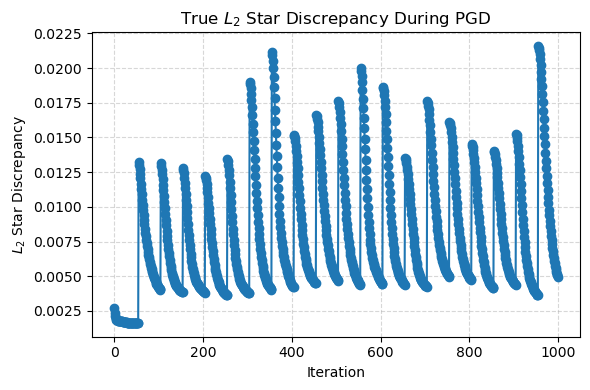

Optimal L2‐star discrepancy achieved: 0.001642


In [37]:
import jax
import jax.numpy as jnp
import optax
import numpy as np

# … your helper-functions here …

# how many points in your set?
n = 300

# build the INITIAL fibonacci set of size n
P_init     = fibonacci_lattice(n)
init_points = np.asarray(P_init).astype(np.float64)

# now P and best_P both start from the same n-point set
P      = P_init
best_P = P_init
# ADAM optimizer setup
learning_rate = 5e-4
optimizer     = optax.adam(learning_rate)

# noise-injection hyper-parameters
n_iters    = 1000
patience   = 50
flat_eps   = 1e-6
noise_scale= 0.1

# … all your existing setup …
opt_state     = optimizer.init(P)

# track true L2‐star discrepancy over time
l2_history = []


# PRNG
key = jax.random.PRNGKey(42)

loss_fn       = lambda P: L2_smoothed(P)
loss_and_grad = jax.value_and_grad(loss_fn)
opt_state     = optimizer.init(P)


best_loss, _ = loss_and_grad(P)
stagnation = 0
objective_history = []

for i in range(n_iters):
    loss_val, grads = loss_and_grad(P)
    objective_history.append(loss_val)

    # 1) Update “best so far”
    if loss_val + flat_eps < best_loss:
        best_loss = loss_val
        best_P = P
        stagnation = 0
    else:
        stagnation += 1

    # 2) If stagnated for too long, perturb the best iterate
    if stagnation >= patience:
        key, subkey = jax.random.split(key)
        noise = noise_scale * jax.random.normal(subkey, best_P.shape)
        P = jnp.clip(best_P + noise, 0.0, 1.0)
        # reset optimizer state if you like, or continue with same opt_state
        # opt_state = optimizer.init(P)
        stagnation = 0
        # optionally log
        print(f"iter {i}: stagnated → injected noise, loss={best_loss:.6f}")

    # 3) Regular gradient-step from wherever P is now
    updates, opt_state = optimizer.update(grads, opt_state)
    P = optax.apply_updates(P, updates)
    P = jnp.clip(P, 0.0, 1.0)

    l2_history.append(
        L2_discrepancy( np.asarray(P) )
        )

# After the loop, you can choose best_P (with best_loss) or final P


init_points = np.asarray(P_init).astype(np.float64)
best_points = np.asarray(best_P).astype(np.float64)
initial_discrepancy_value = L2_discrepancy(init_points)

# === Side-by-side: point sets ===
# === Side-by-side: point sets ===
fig, axs = plt.subplots(1, 2, figsize=(12, 5))

axs[0].scatter(init_points[:, 0], init_points[:, 1], c='blue', edgecolor='black')
axs[0].set_title("Original Fibonacci Set")
# …

axs[1].scatter(best_points[:, 0], best_points[:, 1], c='green', edgecolor='black')
axs[1].set_title("Best PGD-Optimized Point Set")
# …

# === Side-by-side: heatmaps ===
fig, axs = plt.subplots(1, 2, figsize=(14, 5))

_, max_init = heatmap_from_array(init_points, ax=axs[0])
axs[0].set_title("Initial Fibonacci Heatmap")
axs[0].text(0.5, -0.15, f"Max Local Discrepancy: {max_init:.5f}",
            transform=axs[0].transAxes, ha='center', fontsize=11)

_, max_best = heatmap_from_array(best_points, ax=axs[1])
axs[1].set_title("Best PGD Heatmap")
axs[1].text(0.5, -0.15, f"Max Local Discrepancy: {max_best:.5f}",
            transform=axs[1].transAxes, ha='center', fontsize=11)

# === Output ===
print("Initial L2 discrepancy:", initial_discrepancy_value)
print("Best L2 discrepancy value:", L2_discrepancy(best_points))

dx = best_points[:, 0] - init_points[:, 0]
dy = best_points[:, 1] - init_points[:, 1]

plt.figure(figsize=(6, 6))
plt.quiver(
    init_points[:, 0], init_points[:, 1],
    dx, dy, angles='xy', scale_units='xy', scale=1,
    color='blue', width=0.005
)
plt.scatter(init_points[:, 0], init_points[:, 1], c='red', label='Initial')
plt.scatter(best_points[:, 0], best_points[:, 1], c='green', label='Best')

plt.figure()
plt.plot(objective_history, marker='o')
plt.title("Objective Value During PGD")
plt.xlabel("Iteration")
plt.ylabel("smoothed $L_2$ star Discrepancy")
plt.grid(True)
plt.show()
# …

# === True L2‐star Discrepancy over Iterations ===
plt.figure(figsize=(6,4))
plt.plot(l2_history, marker='o')
plt.title("True $L_2$ Star Discrepancy During PGD")
plt.xlabel("Iteration")
plt.ylabel("$L_2$ Star Discrepancy")
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

best_l2 = min(l2_history)
print(f"Optimal L2‐star discrepancy achieved: {best_l2:.6f}")

iter 64: stagnated → injected noise, loss=0.000001
iter 114: stagnated → injected noise, loss=0.000001
iter 164: stagnated → injected noise, loss=0.000001
iter 214: stagnated → injected noise, loss=0.000001
iter 264: stagnated → injected noise, loss=0.000001
iter 314: stagnated → injected noise, loss=0.000001
iter 364: stagnated → injected noise, loss=0.000001
iter 414: stagnated → injected noise, loss=0.000001
iter 464: stagnated → injected noise, loss=0.000001
iter 514: stagnated → injected noise, loss=0.000001
iter 564: stagnated → injected noise, loss=0.000001
iter 614: stagnated → injected noise, loss=0.000001
iter 664: stagnated → injected noise, loss=0.000001
iter 714: stagnated → injected noise, loss=0.000001
iter 764: stagnated → injected noise, loss=0.000001
iter 814: stagnated → injected noise, loss=0.000001
iter 864: stagnated → injected noise, loss=0.000001
iter 914: stagnated → injected noise, loss=0.000001
iter 964: stagnated → injected noise, loss=0.000001
Initial L2 di

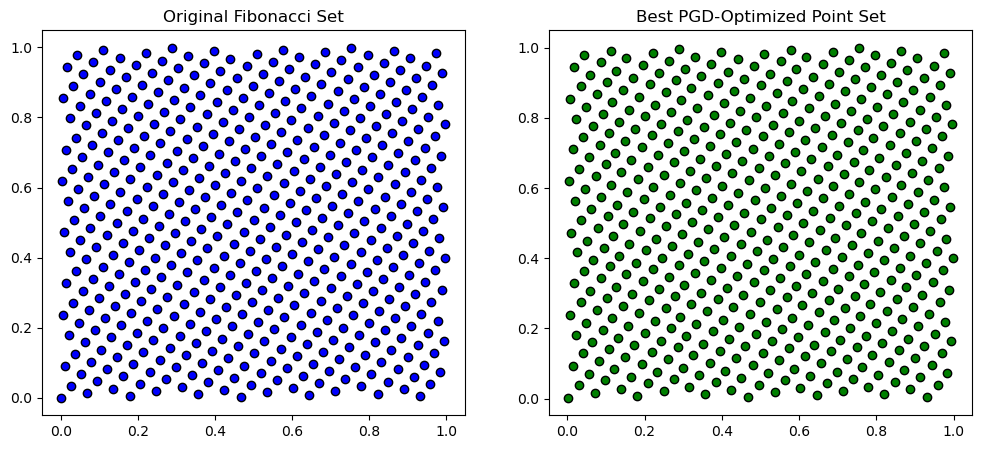

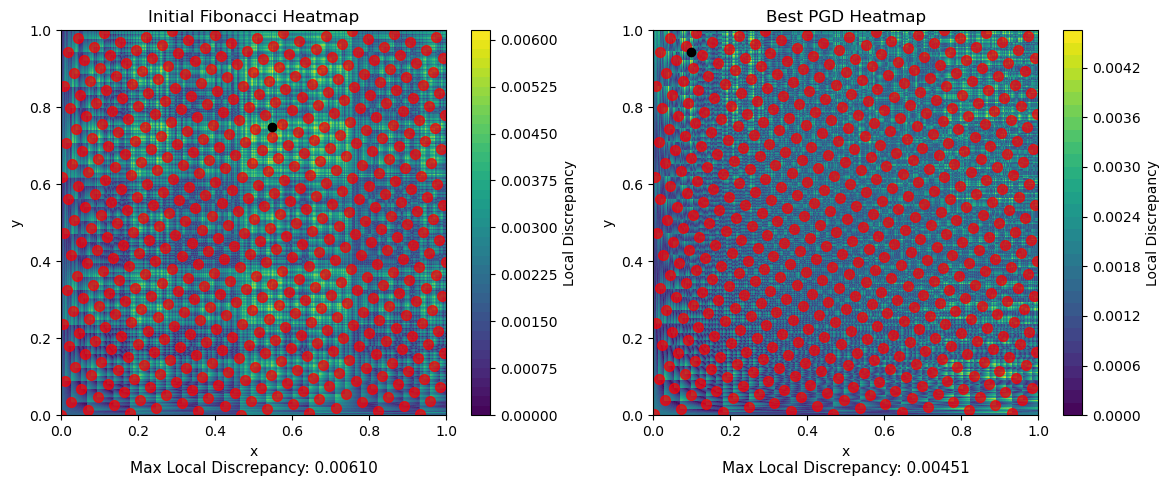

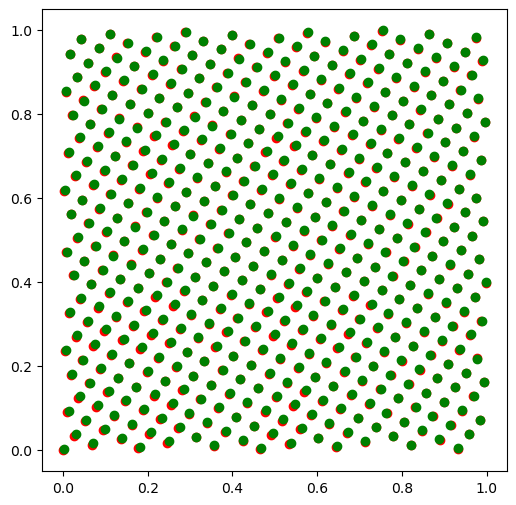

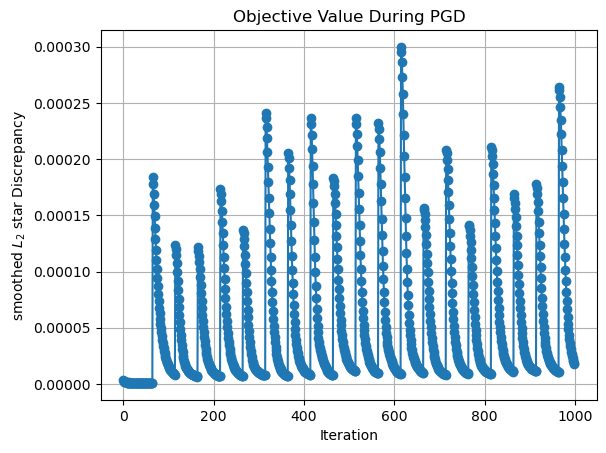

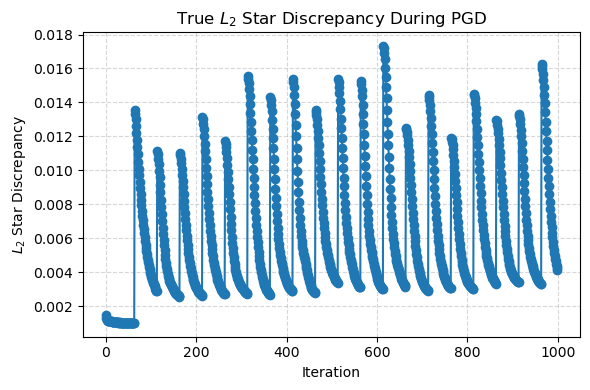

Optimal L2‐star discrepancy achieved: 0.001007


In [39]:
import jax
import jax.numpy as jnp
import optax
import numpy as np

# … your helper-functions here …

# how many points in your set?
n = 500

# build the INITIAL fibonacci set of size n
P_init     = fibonacci_lattice(n)
init_points = np.asarray(P_init).astype(np.float64)

# now P and best_P both start from the same n-point set
P      = P_init
best_P = P_init
# ADAM optimizer setup
learning_rate = 5e-4
optimizer     = optax.adam(learning_rate)

# noise-injection hyper-parameters
n_iters    = 1000
patience   = 50
flat_eps   = 1e-6
noise_scale= 0.1

# … all your existing setup …
opt_state     = optimizer.init(P)

# track true L2‐star discrepancy over time
l2_history = []


# PRNG
key = jax.random.PRNGKey(42)

loss_fn       = lambda P: L2_smoothed(P)
loss_and_grad = jax.value_and_grad(loss_fn)
opt_state     = optimizer.init(P)


best_loss, _ = loss_and_grad(P)
stagnation = 0
objective_history = []

for i in range(n_iters):
    loss_val, grads = loss_and_grad(P)
    objective_history.append(loss_val)

    # 1) Update “best so far”
    if loss_val + flat_eps < best_loss:
        best_loss = loss_val
        best_P = P
        stagnation = 0
    else:
        stagnation += 1

    # 2) If stagnated for too long, perturb the best iterate
    if stagnation >= patience:
        key, subkey = jax.random.split(key)
        noise = noise_scale * jax.random.normal(subkey, best_P.shape)
        P = jnp.clip(best_P + noise, 0.0, 1.0)
        # reset optimizer state if you like, or continue with same opt_state
        # opt_state = optimizer.init(P)
        stagnation = 0
        # optionally log
        print(f"iter {i}: stagnated → injected noise, loss={best_loss:.6f}")

    # 3) Regular gradient-step from wherever P is now
    updates, opt_state = optimizer.update(grads, opt_state)
    P = optax.apply_updates(P, updates)
    P = jnp.clip(P, 0.0, 1.0)

    l2_history.append(
        L2_discrepancy( np.asarray(P) )
        )

# After the loop, you can choose best_P (with best_loss) or final P


init_points = np.asarray(P_init).astype(np.float64)
best_points = np.asarray(best_P).astype(np.float64)
initial_discrepancy_value = L2_discrepancy(init_points)

# === Side-by-side: point sets ===
# === Side-by-side: point sets ===
fig, axs = plt.subplots(1, 2, figsize=(12, 5))

axs[0].scatter(init_points[:, 0], init_points[:, 1], c='blue', edgecolor='black')
axs[0].set_title("Original Fibonacci Set")
# …

axs[1].scatter(best_points[:, 0], best_points[:, 1], c='green', edgecolor='black')
axs[1].set_title("Best PGD-Optimized Point Set")
# …

# === Side-by-side: heatmaps ===
fig, axs = plt.subplots(1, 2, figsize=(14, 5))

_, max_init = heatmap_from_array(init_points, ax=axs[0])
axs[0].set_title("Initial Fibonacci Heatmap")
axs[0].text(0.5, -0.15, f"Max Local Discrepancy: {max_init:.5f}",
            transform=axs[0].transAxes, ha='center', fontsize=11)

_, max_best = heatmap_from_array(best_points, ax=axs[1])
axs[1].set_title("Best PGD Heatmap")
axs[1].text(0.5, -0.15, f"Max Local Discrepancy: {max_best:.5f}",
            transform=axs[1].transAxes, ha='center', fontsize=11)

# === Output ===
print("Initial L2 discrepancy:", initial_discrepancy_value)
print("Best L2 discrepancy value:", L2_discrepancy(best_points))

dx = best_points[:, 0] - init_points[:, 0]
dy = best_points[:, 1] - init_points[:, 1]

plt.figure(figsize=(6, 6))
plt.quiver(
    init_points[:, 0], init_points[:, 1],
    dx, dy, angles='xy', scale_units='xy', scale=1,
    color='blue', width=0.005
)
plt.scatter(init_points[:, 0], init_points[:, 1], c='red', label='Initial')
plt.scatter(best_points[:, 0], best_points[:, 1], c='green', label='Best')

plt.figure()
plt.plot(objective_history, marker='o')
plt.title("Objective Value During PGD")
plt.xlabel("Iteration")
plt.ylabel("smoothed $L_2$ star Discrepancy")
plt.grid(True)
plt.show()
# …

# === True L2‐star Discrepancy over Iterations ===
plt.figure(figsize=(6,4))
plt.plot(l2_history, marker='o')
plt.title("True $L_2$ Star Discrepancy During PGD")
plt.xlabel("Iteration")
plt.ylabel("$L_2$ Star Discrepancy")
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

best_l2 = min(l2_history)
print(f"Optimal L2‐star discrepancy achieved: {best_l2:.6f}")